In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/organizations/uciml/indian-liver-patient-records/indian_liver_patient.csv



Missing Values BEFORE Cleaning:
Age                           0
Gender                        0
Total_Bilirubin               0
Direct_Bilirubin              0
Alkaline_Phosphotase          0
Alamine_Aminotransferase      0
Aspartate_Aminotransferase    0
Total_Protiens                0
Albumin                       0
Albumin_and_Globulin_Ratio    4
Dataset                       0
dtype: int64

Missing Values AFTER Cleaning:
Age                           0
Gender                        0
Total_Bilirubin               0
Direct_Bilirubin              0
Alkaline_Phosphotase          0
Alamine_Aminotransferase      0
Aspartate_Aminotransferase    0
Total_Protiens                0
Albumin                       0
Albumin_and_Globulin_Ratio    0
Dataset                       0
dtype: int64

Duplicates Removed: 13
Shape after removing outliers: (387, 11)


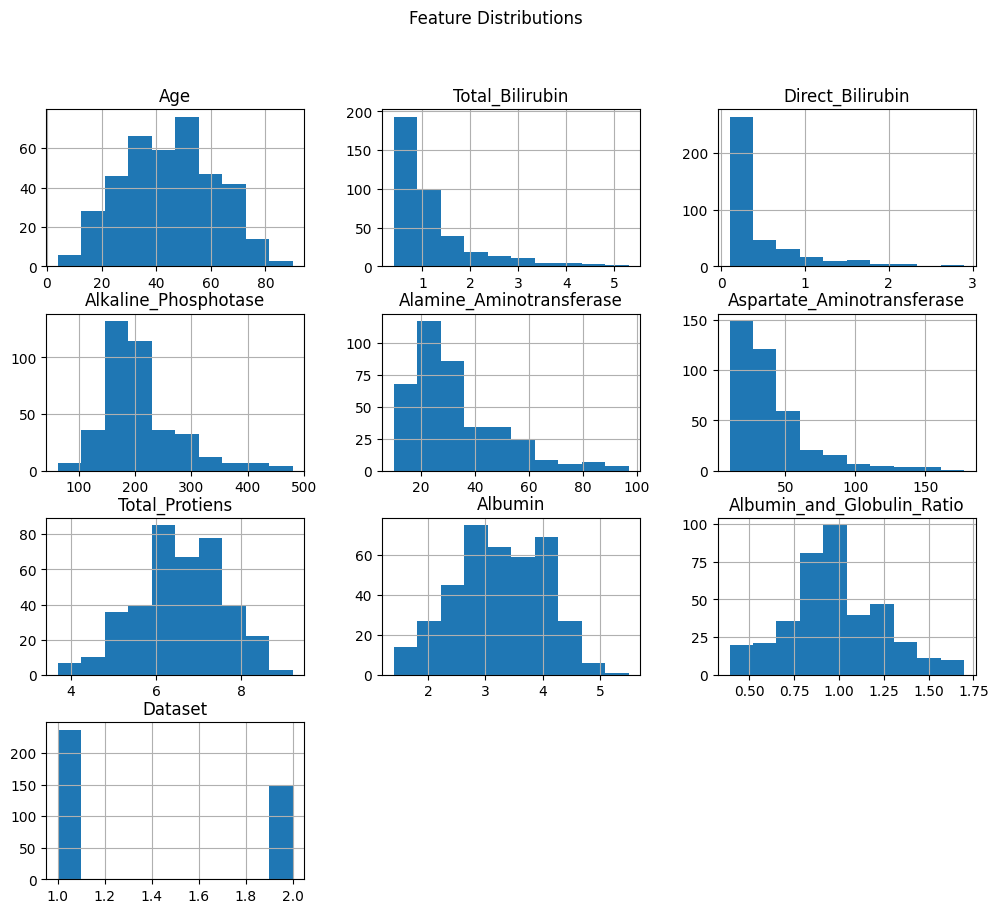

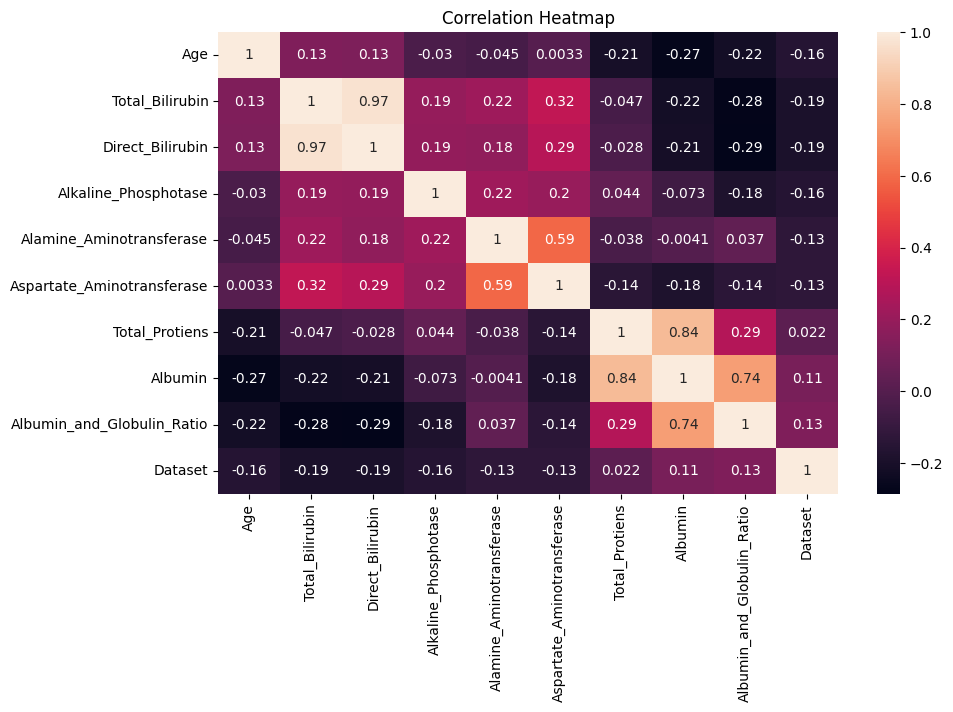

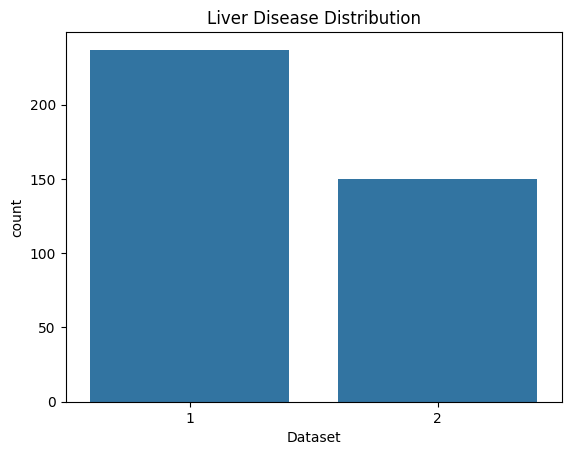


Final Dataset Shape: (387, 11)

Final Data Preview:
   Age  Gender  Total_Bilirubin  Direct_Bilirubin  Alkaline_Phosphotase  \
0   65  Female              0.7               0.1                   187   
3   58    Male              1.0               0.4                   182   
4   72    Male              3.9               2.0                   195   
5   46    Male              1.8               0.7                   208   
6   26  Female              0.9               0.2                   154   

   Alamine_Aminotransferase  Aspartate_Aminotransferase  Total_Protiens  \
0                        16                          18             6.8   
3                        14                          20             6.8   
4                        27                          59             7.3   
5                        19                          14             7.6   
6                        16                          12             7.0   

   Albumin  Albumin_and_Globulin_Ratio  Datas

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

#Load DataSet

data=pd.read_csv('/kaggle/input/datasets/organizations/uciml/indian-liver-patient-records/indian_liver_patient.csv')
data.head()

#Check Missing Values BEFORE

print("\nMissing Values BEFORE Cleaning:")
print(data.isnull().sum())

# Handle Missing Values

for col in data.columns:
    try:
        data[col] = pd.to_numeric(data[col])
    except:
        pass
    
num_cols = data.select_dtypes(include=['number']).columns
cat_cols = data.select_dtypes(include=['object']).columns
data[num_cols] = data[num_cols].fillna(data[num_cols].mean())
for col in cat_cols:
    data[col] = data[col].fillna(data[col].mode()[0])
    
#Check Missing Values AFTER

print("\nMissing Values AFTER Cleaning:")
print(data.isnull().sum())

#Remove Duplicates

before = data.shape[0]
data = data.drop_duplicates()
after = data.shape[0]

print(f"\nDuplicates Removed: {before - after}")

#Handle Outliers

Q1 = data[num_cols].quantile(0.25)
Q3 = data[num_cols].quantile(0.75)
IQR = Q3 - Q1

data = data[~((data[num_cols] < (Q1 - 1.5 * IQR)) |
              (data[num_cols] > (Q3 + 1.5 * IQR))).any(axis=1)]

print("Shape after removing outliers:", data.shape)

#Visualization

data.hist(figsize=(12,10))
plt.suptitle("Feature Distributions")
plt.show()

plt.figure(figsize=(10,6))
sns.heatmap(data.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

if 'Dataset' in data.columns:
    sns.countplot(x='Dataset', data=data)
    plt.title("Liver Disease Distribution")
    plt.show()


print("\nFinal Dataset Shape:", data.shape)
print("\nFinal Data Preview:")
print(data.head())